# NBModelEva

This notebook evaluates the tuned Multinomial Naive Bayes model on the held-out Yelp test set and presents its main classification results.

In [1]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from evaluation_utils import (
    load_yelp_split,
    print_evaluation,
    print_top_terms,
    validate_pipeline_labels,
)


PART_B_DIR = Path.cwd().parents[0]
DATA_FILE = PART_B_DIR / "data" / "yelp_clean.csv"
MODEL_FILE = PART_B_DIR / "models" / "nb_tuned.joblib"

## Load Tuned Model

The tuned Multinomial Naive Bayes pipeline saved during hyperparameter selection is loaded and checked before evaluation.

In [2]:
# Reload the tuned Yelp Multinomial Naive Bayes pipeline saved by Q3.
pipeline = joblib.load(MODEL_FILE)
validate_pipeline_labels(pipeline, "Multinomial Naive Bayes")

## Model Evaluation

The model is evaluated on unseen test reviews using accuracy, precision, recall and F1-score, together with its most influential terms.

In [3]:
# Recreate the same held-out test set used throughout Part B.
df, X_train, X_test, y_train, y_test = load_yelp_split(DATA_FILE)

print_top_terms(pipeline, X_train, y_train, "Multinomial Naive Bayes")
print_evaluation(pipeline, X_test, y_test, "Multinomial Naive Bayes")

=== Top Terms Per Sentiment Class (Multinomial Naive Bayes) ===

negative:
give zero, negative star, place horrible, zero star, management not, never recommend, horrible food, horrible service, poor customer, service horrible

neutral:
place ok, three star, give three, not amazing, pretty average, nothing stand, not spectacular, decent enough, decent selection, little sweet

positive:
hand best, definitely back, definitely come, overall great, would highly, food amazing, family own, glad find, far favorite, worth every

=== Q4: Tuned Yelp Multinomial Naive Bayes 3-Class Classification Report ===
              precision    recall  f1-score   support

    negative     0.8099    0.7329    0.7695      2400
     neutral     0.4239    0.6217    0.5041      1200
    positive     0.8578    0.7392    0.7941      2400

    accuracy                         0.7132      6000
   macro avg     0.6972    0.6979    0.6892      6000
weighted avg     0.7518    0.7132    0.7262      6000

=== Q4: Tuned Ye

### Confusion Matrix

The confusion matrix shows the tuned Multinomial Naive Bayes model's correct predictions and misclassifications for each sentiment class.

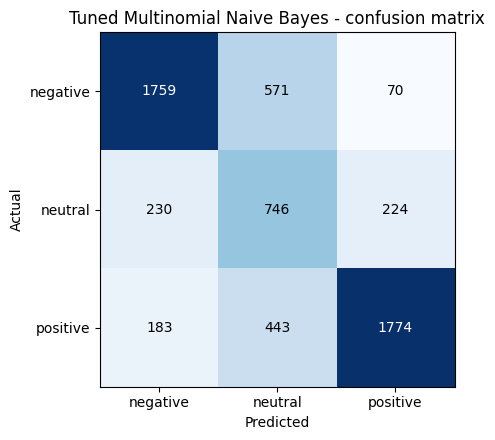

negative predicted as positive: 70
positive predicted as negative: 183
neutral missed entirely       : 454 of 1200


In [4]:
# Same confusion matrix as above, drawn as a labelled grid so it can go in the report.
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, pipeline.predict(X_test), labels=labels)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(3), labels)
ax.set_yticks(range(3), labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Tuned Multinomial Naive Bayes - confusion matrix")

# Write the count into each square, in white on the darker cells so it stays readable.
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("nb_confusion_matrix.png", dpi=120)
plt.show()

# The two polar classes are rarely confused with each other; nearly all the error is
# neutral being pulled toward one of the poles, or a pole being called neutral.
print("negative predicted as positive:", cm[0, 2])
print("positive predicted as negative:", cm[2, 0])
print("neutral missed entirely       :", cm[1, 0] + cm[1, 2], "of", cm[1].sum())